<a href="https://colab.research.google.com/github/sabdashy/Matkul_MachineLearning/blob/tugas/Notebook/Tugas/Tugas12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
path = "/content/gdrive/MyDrive/MataKuliahSTTNF/Semester7/MachineLearning/praktikum_ml/praktikum12"

In [3]:
# Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams['figure.figsize'] = (8, 6)

In [4]:
df = pd.read_csv(path + '/data/data.csv')

# Drop kolom yang tidak relevan
df = df.drop(['id', 'Unnamed: 32'], axis=1)

# Encode diagnosis: M=1, B=0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Pisahkan fitur dan label
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (569, 30)
Shape y: (569,)


In [5]:
# Membagi data menjadi data latih (80%) dan data uji (20%)
# stratify=y memastikan proporsi kelas pada data train dan test tetap seimbang
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
# Membuat objek StandardScaler untuk menstandarkan data (mean = 0, std = 1)
scaler = StandardScaler()

# Melakukan scaling pada data training dan menghitung parameter scaling dari data training
X_train_scaled = scaler.fit_transform(X_train)

# Melakukan scaling pada data testing menggunakan parameter dari data training
X_test_scaled = scaler.transform(X_test)

In [15]:
# Membuat model SVM dengan kernel RBF tanpa menggunakan PCA
svm_no_pca = SVC(kernel='rbf', gamma='scale')

# Melatih model SVM menggunakan data training yang sudah discaling
svm_no_pca.fit(X_train_scaled, y_train)

# Melakukan prediksi label pada data testing
y_pred_no_pca = svm_no_pca.predict(X_test_scaled)

# Menghitung akurasi model SVM tanpa PCA
acc_no_pca = accuracy_score(y_test, y_pred_no_pca)

# Menampilkan nilai akurasi dan classification report (precision, recall, f1-score)
print("\n===== AKURASI MODEL TANPA PCA =====")
print("Accuracy :", acc_no_pca)
print(classification_report(y_test, y_pred_no_pca))


===== AKURASI MODEL TANPA PCA =====
Accuracy : 0.9736842105263158
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [14]:
# Membuat PCA dengan 3 komponen utama
pca = PCA(n_components=3)

# Melakukan PCA pada data training dan mempelajari komponen utamanya
X_train_pca = pca.fit_transform(X_train_scaled)

# Mentransformasikan data testing ke ruang PCA yang sama
X_test_pca  = pca.transform(X_test_scaled)

print("\nExplained Variance Ratio (3 Komponen):")
# Menampilkan proporsi variansi data yang dijelaskan oleh masing-masing komponen PCA
print(pca.explained_variance_ratio_)
# Menampilkan total variansi data yang berhasil dipertahankan oleh 3 komponen PCA
print("Total Variance:", np.sum(pca.explained_variance_ratio_))


Explained Variance Ratio (3 Komponen):
[0.44593522 0.18545255 0.09584641]
Total Variance: 0.7272341886241546


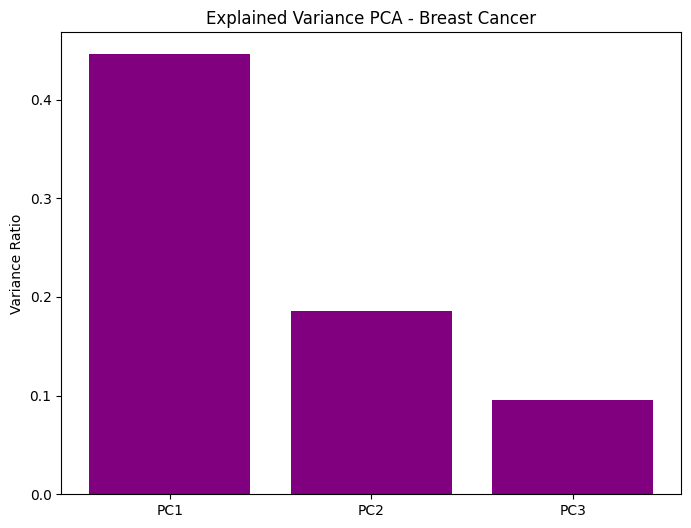

In [9]:
# Membuat grafik batang untuk melihat kontribusi masing-masing komponen PCA
plt.bar(['PC1','PC2','PC3'], pca.explained_variance_ratio_, color='purple')
plt.title("Explained Variance PCA - Breast Cancer")
plt.ylabel("Variance Ratio")
# Menampilkan grafik explained variance PCA
plt.show()

In [10]:
# Membuat model SVM dengan kernel RBF menggunakan data hasil PCA
svm_pca = SVC(kernel='rbf', gamma='scale')
# Melatih model SVM menggunakan data training yang sudah direduksi dengan PCA
svm_pca.fit(X_train_pca, y_train)

# Melakukan prediksi pada data testing hasil PCA
y_pred_pca = svm_pca.predict(X_test_pca)

# Menghitung akurasi model SVM dengan PCA
acc_pca = accuracy_score(y_test, y_pred_pca)

# Menampilkan akurasi dan classification report model SVM dengan PCA
print("\n===== AKURASI MODEL DENGAN PCA =====")
print("Accuracy :", acc_pca)
print(classification_report(y_test, y_pred_pca))


===== AKURASI MODEL DENGAN PCA =====
Accuracy : 0.956140350877193
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        72
           1       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



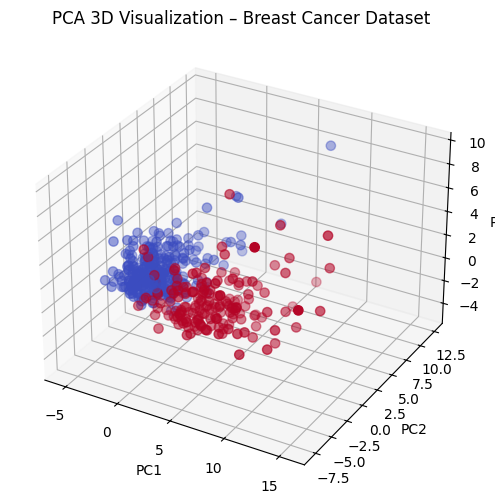

In [11]:
# Membuat kanvas dan sumbu 3D untuk visualisasi PCA
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Menampilkan sebaran data training dalam ruang PCA 3D dengan warna sesuai kelas
scatter = ax.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    X_train_pca[:, 2],
    c=y_train, cmap='coolwarm', s=45
)

# Memberi judul dan label sumbu pada grafik PCA 3D
ax.set_title("PCA 3D Visualization – Breast Cancer Dataset")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

# Menampilkan visualisasi PCA 3D
plt.show()

In [13]:
# Menampilkan perbandingan akurasi model SVM sebelum dan sesudah menggunakan PCA
print("\n==============================================")
print("   PERBANDINGAN AKURASI SVM: TANPA PCA VS PCA")
print("==============================================")
print(f"Akurasi SVM tanpa PCA : {acc_no_pca:.4f}")
print(f"Akurasi SVM dengan PCA: {acc_pca:.4f}")
print("Total Variansi PCA     :", np.sum(pca.explained_variance_ratio_))
print("==============================================")


   PERBANDINGAN AKURASI SVM: TANPA PCA VS PCA
Akurasi SVM tanpa PCA : 0.9737
Akurasi SVM dengan PCA: 0.9561
Total Variansi PCA     : 0.7272341886241546
